# Práctico Parte II - Optativa Series de Tiempo

### Consigna

Tomando como orientación el jupyter-notebook "GARCH_Modelo_de_activos.ipynb", se pide:
- Seleccionar de Yahoo Finance https://es.finance.yahoo.com/ un activo, un índice, o un tipo de cambio. Descargar una serie con datos diarios que abarque al menos 10 años.
- Aplicar la transformación .pctchange y seleccionar una de las columnas ['Close'] o ['Adj Close'].
- Si el test ADF no rechaza la existencia de una raíz unitaria para esta transformación, elija otro conjunto de datos.
- Plotee los valores y el cuadrado de los valores, y ajuste un modelo GARCH adecuado. Procure que el modelo sea simple ($p, q <= 3$).
- Muestre en un gráfico que la volatilidad se adecua a la serie que se está modelando.
- Entrene el modelo y realice una predicción de 5 valores de la volatilidad.

## Cargar paquetes

In [2]:
!pip install arch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.7/981.7 kB 15.3 MB/s eta 0:00:00


In [3]:
#import pandas_datareader.data as web
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from arch import arch_model
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from datetime import datetime, timedelta

## Volatilidad de S&P500

In [4]:
# Descargar datos de Yahoo Finance para el S&P500
ticker = '^GSPC'  # Símbolo del S&P500
start_date = '2013-12-02'
end_date = '2023-12-02'

data = yf.download(ticker,
                   start = start_date,
                   end = end_date)
data

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2013-12-02,1806.550049,1810.020020,1798.599976,1800.900024,1800.900024,3095430000
2013-12-03,1800.099976,1800.099976,1787.849976,1795.150024,1795.150024,3475680000
2013-12-04,1793.150024,1799.800049,1779.089966,1792.810059,1792.810059,3610540000
2013-12-05,1792.819946,1792.819946,1783.380005,1785.030029,1785.030029,3336880000
2013-12-06,1788.359985,1806.040039,1788.359985,1805.089966,1805.089966,3150030000
...,...,...,...,...,...,...
2023-11-27,4554.859863,4560.520020,4546.319824,4550.430176,4550.430176,3403990000
2023-11-28,4545.549805,4568.140137,4540.509766,4554.890137,4554.890137,3586240000
2023-11-29,4571.839844,4587.640137,4547.149902,4550.580078,4550.580078,4418760000


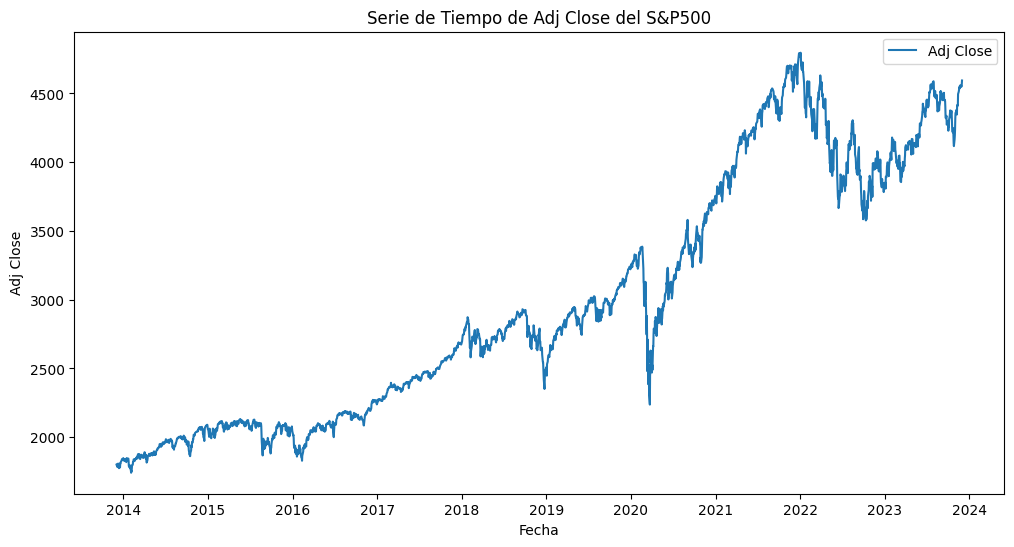

In [5]:
# Graficar la serie de tiempo de "Adj Close"
plt.figure(figsize=(12, 6))
plt.plot(data['Adj Close'], label='Adj Close')
plt.title('Serie de Tiempo de Adj Close del S&P500')
plt.xlabel('Fecha')
plt.ylabel('Adj Close')
plt.legend()
plt.show()

In [6]:
# Calculo los retornos diarios a partir de los datos de la columna "Adj Close"
returns = 100 * data['Adj Close'].pct_change().dropna()
returns

Date
2013-12-03   -0.319285
2013-12-04   -0.130349
2013-12-05   -0.433957
2013-12-06    1.123787
2013-12-09    0.181710
                ...   
2023-11-27   -0.195416
2023-11-28    0.098012
2023-11-29   -0.094625
2023-11-30    0.378407
2023-12-01    0.587374
Name: Adj Close, Length: 2517, dtype: float64

Valor del Estadistico del Test ADF: -15.92809077357393
p-valor: 7.785746308633607e-29


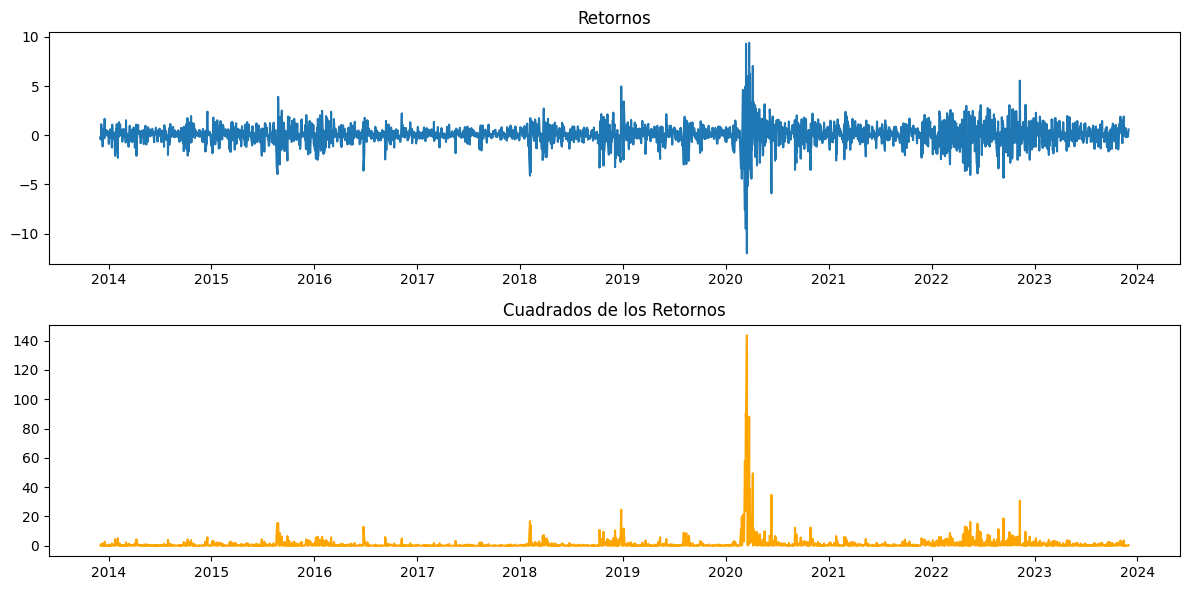

In [7]:
# Aplicar la prueba de ADF
result_adf = adfuller(returns)
print(f'Valor del Estadistico del Test ADF: {result_adf[0]}')
print(f'p-valor: {result_adf[1]}')

# Si el p-value es mayor que 0.05, selecciona otro conjunto de datos
if result_adf[1] > 0.05:
    print("La serie tiene una raíz unitaria. Por favor, selecciona otro conjunto de datos.")
else:
    # Ploteo de los valores y el cuadrado de los valores
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.plot(returns)
    plt.title('Retornos')

    plt.subplot(2, 1, 2)
    plt.plot(returns ** 2, color='orange')
    plt.title('Cuadrados de los Retornos')

    plt.tight_layout()
    plt.show()

## PACF

Observamos el gráfico de PACF de los cuadrados de los retornos:

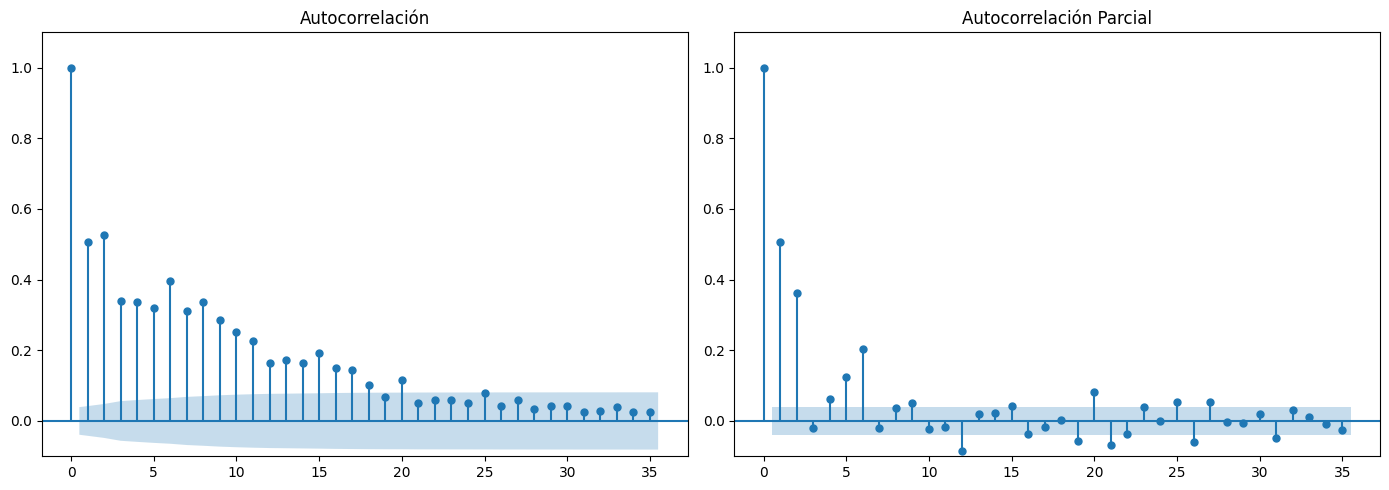

In [8]:
# Ploteo de ACF y PACF en un subplot de 1 fila y 2 columnas
plt.figure(figsize=(14, 5))

# Gráfico de ACF
plt.subplot(1, 2, 1)
acf_plot = plot_acf(returns**2,
                    title='Autocorrelación',
                    ax=plt.gca())
plt.ylim(-0.10, 1.1)

# Gráfico de PACF
plt.subplot(1, 2, 2)
pacf_plot = plot_pacf(returns**2,
                      title='Autocorrelación Parcial',
                      ax=plt.gca())
plt.ylim(-0.10, 1.1)

plt.tight_layout()
plt.show()

## Ajustar GARCH(p,q)

Ajustar un modelo GARCH en finanzas tiene sentido porque los precios de las acciones y otros activos financieros no tienen siempre la misma volatilidad. A veces son más volátiles y a veces menos. Los modelos GARCH ayudan a entender y predecir estos cambios en la volatilidad. Son útiles para manejar riesgos en inversiones, pronosticar cómo podría cambiar la volatilidad en el futuro y se basan en la idea de que los mercados financieros son impredecibles y pueden cambiar rápidamente. En resumen, los modelos GARCH son herramientas valiosas para entender y gestionar el riesgo en el mundo financiero.

In [25]:
model = arch_model(returns,
                   p = 2,
                   q = 2)

In [26]:
model_fit = model.fit()

Iteration:      1,   Func. Count:      8,   Neg. LLF: 16861.709479657657
Iteration:      2,   Func. Count:     20,   Neg. LLF: 12632.492091854981
Iteration:      3,   Func. Count:     31,   Neg. LLF: 5176.770809015708
Iteration:      4,   Func. Count:     40,   Neg. LLF: 4347.140556904365
Iteration:      5,   Func. Count:     48,   Neg. LLF: 3447.609840835654
Iteration:      6,   Func. Count:     57,   Neg. LLF: 3188.2084866542896
Iteration:      7,   Func. Count:     64,   Neg. LLF: 3187.9209935561266
Iteration:      8,   Func. Count:     71,   Neg. LLF: 3187.9890928583145
Iteration:      9,   Func. Count:     79,   Neg. LLF: 3187.83082434706
Iteration:     10,   Func. Count:     86,   Neg. LLF: 3187.807656542695
Iteration:     11,   Func. Count:     93,   Neg. LLF: 3187.8050359839053
Iteration:     12,   Func. Count:    100,   Neg. LLF: 3187.8048260367545
Iteration:     13,   Func. Count:    107,   Neg. LLF: 3187.8047859797753
Iteration:     14,   Func. Count:    114,   Neg. LLF: 318

In [27]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3187.80
Distribution:                  Normal   AIC:                           6387.61
Method:            Maximum Likelihood   BIC:                           6422.59
                                        No. Observations:                 2517
Date:                Mon, Dec 11 2023   Df Residuals:                     2516
Time:                        19:22:37   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0790  1.455e-02      5.428  5.688e-08 [5.047e-02,  0.108]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.0686  1.705e-02      4.026  5.672e-05 [3.522e-02,  0.102]
alpha[1]       0.1844  3.652e-02      5.047  4.480e-07   [  0.113,  0.256]
alpha[2]       0.1687  3.597e-02      4.691  2.721e-06 [9.824e-02,  0.239]
beta[1]    5.9712e-19      0.101  5.900e-18      1.000   [ -0.198,  0.198]
beta[2]        0.5952  7.868e-02      7.565  3.891e-14   [  0.441,  0.749]
==========================================================================

Covariance estimator: robust
"""

In [13]:
# Creo una lista para almacenar las predicciones
rolling_predictions = []

# Defino el tamaño del conjunto de prueba como 504 días (los dias hábiles de 2 años)
test_size = 2 * 252

for i in range(test_size):

    # Separo el conjunto de entrenamiento para el modelo en cada iteración
    train = returns[:-(test_size-i)]

    # Configura y ajusta el modelo GARCH
    model = arch_model(train,
                       p=2,
                       q=2)
    model_fit = model.fit(disp='off')

    # Hago la predicción de un paso hacia adelante y almacena la raíz cuadrada de la varianza predicha
    pred = model_fit.forecast(horizon=1)
    rolling_predictions.append(np.sqrt(pred.variance.values[-1,:][0]))


In [14]:
# Guardo como una Serie de pandas las predicciones y establezco el índice con las fechas correspondientes del conjunto de prueba
rolling_predictions = pd.Series(rolling_predictions,
                                index = returns.index[-test_size:])

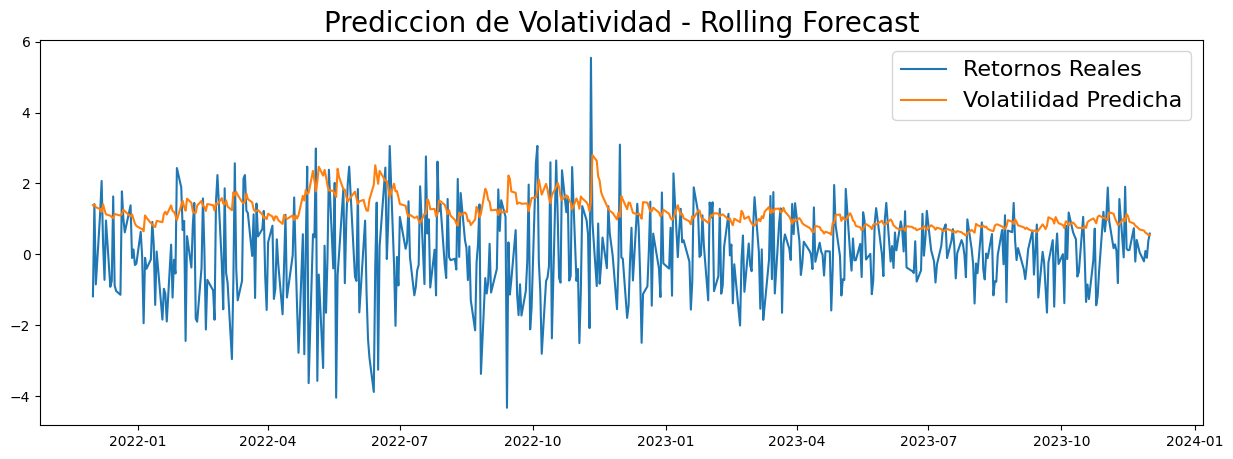

In [15]:
plt.figure(figsize=(15,5))
# Grafico la serie temporal de Retornos del conjunto de prueba
true, = plt.plot(returns[-test_size:])
# Grafica las predicciones de la volatilidad
preds, = plt.plot(rolling_predictions)
plt.title('Prediccion de Volatividad - Rolling Forecast', fontsize=20)
plt.legend(['Retornos Reales', 'Volatilidad Predicha'], fontsize=16)

## Rolling Forecast

In [16]:
# Tamaño del conjunto de prueba
test_size = 252 * 2
# Horizonte de pronóstico(Aproximadamente los dias habiles de un mes)
forecast_horizon = 20

# Inicializar una lista para almacenar los pronósticos
rolling_predictions = []

# Implementar el rolling forecast
for i in range(test_size):
    # Seleccionar la ventana de entrenamiento actual
    train_window = returns[:-(test_size-i)]

    # Ajustar el modelo GARCH(5,5)
    model = arch_model(train_window,
                       p=2,
                       q=2)
    model_fit = model.fit(disp='off')

    # Realizar el pronóstico para el horizonte especificado
    pred = model_fit.forecast(horizon=forecast_horizon)

    # Agregar los pronósticos a la lista
    rolling_predictions.append(np.sqrt(pred.variance.values[-1, :][0]))

In [17]:
# Guardo como una Serie de pandas las predicciones y establezco el índice con las fechas correspondientes del conjunto de prueba
rolling_predictions = pd.Series(rolling_predictions,
                                index = returns.index[-test_size:])

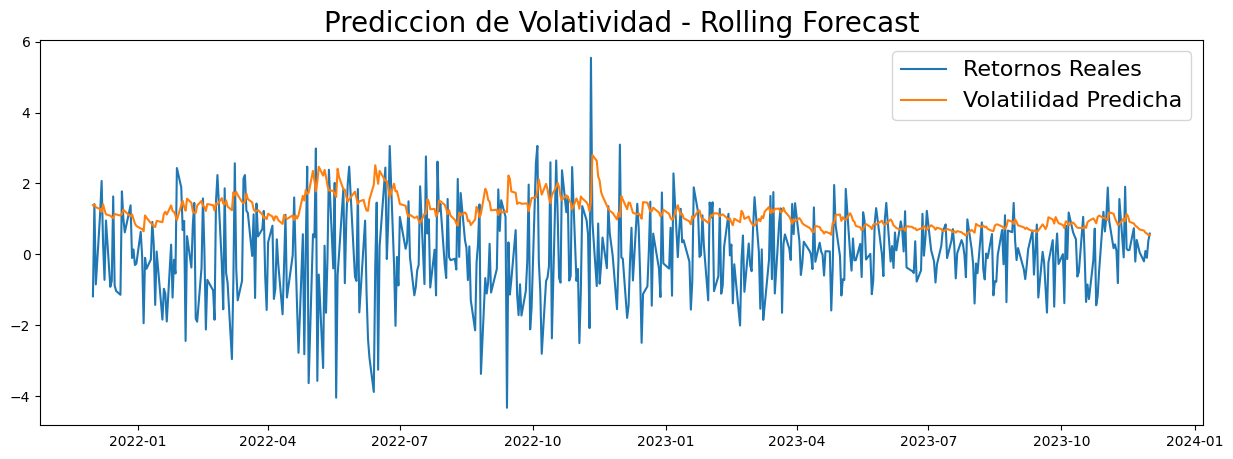

In [18]:
plt.figure(figsize=(15,5))
# Grafico la serie temporal de Retornos del conjunto de prueba
true, = plt.plot(returns[-test_size:])
# Grafica las predicciones de la volatilidad
preds, = plt.plot(rolling_predictions)
plt.title('Prediccion de Volatividad - Rolling Forecast', fontsize=20)
plt.legend(['Retornos Reales', 'Volatilidad Predicha'], fontsize=16)

# Predecir 5 días

In [19]:
# Uso la serie temporal completa como conjunto de entrenamiento
train = returns

# Creo y entreno el modelo GARCH a la serie temporal de retornos
model = arch_model(train,
                   p = 2,
                   q = 2)
model_fit = model.fit(disp='off')

In [20]:
# Defino la cantidad de dias a predecir
horiz = 5

# Hago la predicción para los dias especificados usando el modelo ajustado
pred = model_fit.forecast(horizon=horiz)

# Creo fechas futuras basadas en la última fecha en el conjunto de datos original y el horizonte de predicción
future_dates = [returns.index[-1] + timedelta(days=i) for i in range(1, horiz+1)]

# Convierto los valores de la varianze en una Serie de pandas con las fechas futuras
pred = pd.Series(np.sqrt(pred.variance.values[-1, :]), index=future_dates)

Text(0.5, 1.0, 'Prediccion de Volatibilidad - Proximos 5 días')

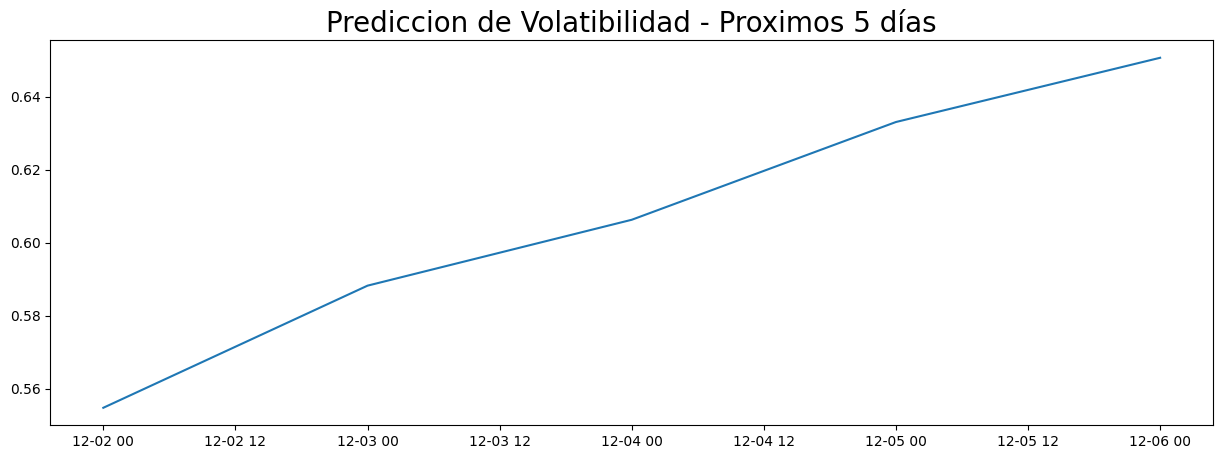

In [21]:
plt.figure(figsize=(15,5))
plt.plot(pred)
plt.title(f'Prediccion de Volatibilidad - Proximos {horiz} días', fontsize=20)